# Model Results Analysis — The Big Short MLOps Project

This notebook analyzes the results of `model_train` + `model_evaluate`:
1. Validation vs test performance gap (drift evidence)
2. Year-by-year degradation curve (2003-2008)
3. SHAP explainability for the selected model
4. Calibration and prediction distribution analysis

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

In [2]:
with open('../data/08_reporting/train_metadata.json') as f:
    train_metadata = json.load(f)

print(f"Modelo: {train_metadata['selected_model_family']}")
print(f"Model URI: {train_metadata['model_uri']}")

Modelo: gradient_boosting
Model URI: runs:/294c369e2ec3400191aa8f0ac4cbf028/model


In [3]:
mlflow.set_tracking_uri('sqlite:///../mlflow.db')

model_uri = train_metadata['model_uri']
print(f'Loading model from: {model_uri}')

model = mlflow.sklearn.load_model(model_uri)
feature_columns = train_metadata['feature_columns']

print(f'Model type: {type(model)}')
print(f'Number of features: {len(feature_columns)}')

Loading model from: runs:/294c369e2ec3400191aa8f0ac4cbf028/model


Model type: <class 'sklearn.pipeline.Pipeline'>
Number of features: 24


## 1. Load results

In [4]:
with open('../data/08_reporting/model_training_metrics.json') as f:
    final_metrics = json.load(f)

with open('../data/08_reporting/train_metadata.json') as f:
    train_metadata = json.load(f)

predictions = pd.read_parquet('../data/07_model_output/model_test_predictions.parquet')

print(f"Selected model: {final_metrics['selected_model_family']}")
print(f"Threshold: {final_metrics['selected_threshold']:.4f}")
print(f"Test rows: {final_metrics['n_test_rows']:,}")

Selected model: gradient_boosting
Threshold: 0.1062
Test rows: 288,631


## 2. Validation vs Test Performance Gap

This is the core evidence of drift: the model looks excellent when validated
internally (same period as training data), but degrades sharply when applied
to loans originated after the training cutoff.

   Metric  Validation (2000-2002)  Test (2003-2008)
  ROC-AUC                0.864088          0.601128
   Recall                0.333922          0.057143
Precision                0.165644          0.199041
       F1                0.221441          0.088794


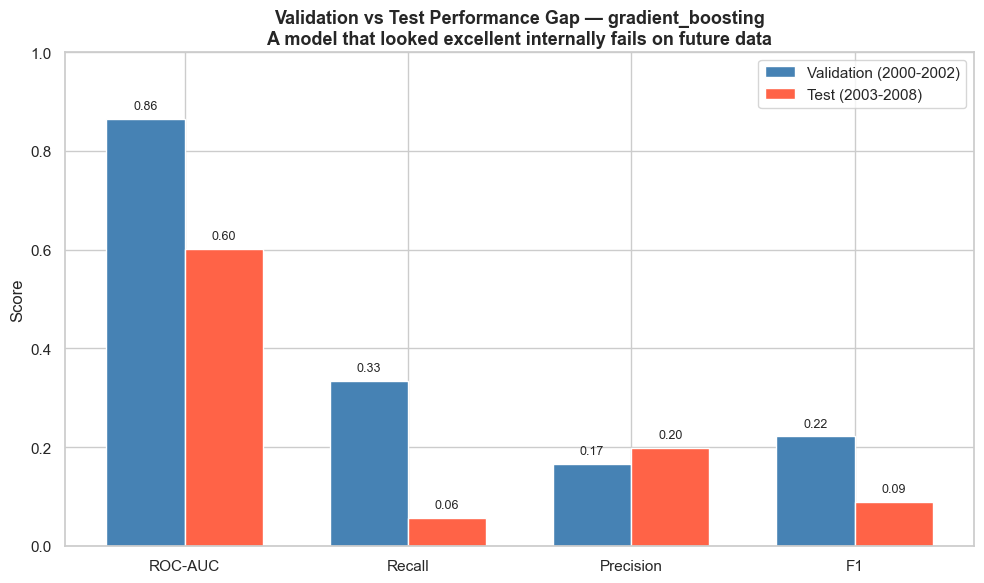

In [5]:
# Find the best candidate's validation metrics for the selected model family
best_family = final_metrics['selected_model_family']
val_summary = next(
    s for s in train_metadata['model_summaries']
    if s['model_family'] == best_family
)

comparison = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Recall', 'Precision', 'F1'],
    'Validation (2000-2002)': [
        val_summary.get('val_roc_auc', np.nan),
        val_summary.get('val_recall', np.nan),
        val_summary.get('val_precision', np.nan),
        val_summary.get('val_f1', np.nan),
    ],
    'Test (2003-2008)': [
        final_metrics.get('final_test_roc_auc', np.nan),
        final_metrics.get('final_test_recall', np.nan),
        final_metrics.get('final_test_precision', np.nan),
        final_metrics.get('final_test_f1', np.nan),
    ],
})

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison['Validation (2000-2002)'], width,
       label='Validation (2000-2002)', color='steelblue')
ax.bar(x + width/2, comparison['Test (2003-2008)'], width,
       label='Test (2003-2008)', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'])
ax.set_ylabel('Score')
ax.set_title(f'Validation vs Test Performance Gap — {best_family}\n'
             'A model that looked excellent internally fails on future data',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

for i, (val, test) in enumerate(zip(comparison['Validation (2000-2002)'],
                                       comparison['Test (2003-2008)'])):
    ax.text(i - width/2, val + 0.02, f'{val:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, test + 0.02, f'{test:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Year-by-Year Degradation (2003-2008)

Breaking down the aggregate test metrics by origination year reveals the
progressive nature of the drift — performance should worsen as we approach
the 2007-2008 crisis peak.

In [6]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

# Reload the cleaned dataset to recover the 'year' column for each test loan
full_data = pd.read_parquet('../data/03_primary/model_input_cleaned.parquet')
test_years = full_data[full_data['year'] >= 2003][['loan_sequence_number', 'year']].reset_index(drop=True)

# Align by position (predictions preserves the original row order from features_test)
if 'loan_sequence_number' in predictions.columns:
    predictions_with_year = predictions.merge(
        test_years, on='loan_sequence_number', how='left'
    )
else:
    # fallback: assume same order
    predictions_with_year = predictions.copy()
    predictions_with_year['year'] = test_years['year'].values[:len(predictions)]

yearly_metrics = []
for year in sorted(predictions_with_year['year'].dropna().unique()):
    subset = predictions_with_year[predictions_with_year['year'] == year]
    if subset['actual_default'].nunique() < 2:
        continue
    yearly_metrics.append({
        'year': int(year),
        'n_loans': len(subset),
        'default_rate': subset['actual_default'].mean(),
        'roc_auc': roc_auc_score(subset['actual_default'], subset['probability_default']),
        'recall': recall_score(subset['actual_default'], subset['prediction'], zero_division=0),
        'precision': precision_score(subset['actual_default'], subset['prediction'], zero_division=0),
        'f1': f1_score(subset['actual_default'], subset['prediction'], zero_division=0),
    })

yearly_df = pd.DataFrame(yearly_metrics)
print(yearly_df.to_string(index=False))

 year  n_loans  default_rate  roc_auc   recall  precision       f1
 2003    39999      0.030926 0.816068 0.240905   0.225929 0.233177
 2004    40000      0.051225 0.711377 0.114202   0.232604 0.153191
 2005    89998      0.081124 0.553919 0.047665   0.143624 0.071575
 2006    39998      0.187059 0.535531 0.029270   0.207977 0.051318
 2007    40000      0.219100 0.561695 0.051118   0.273004 0.086112
 2008    38636      0.076405 0.628877 0.052507   0.139766 0.076336


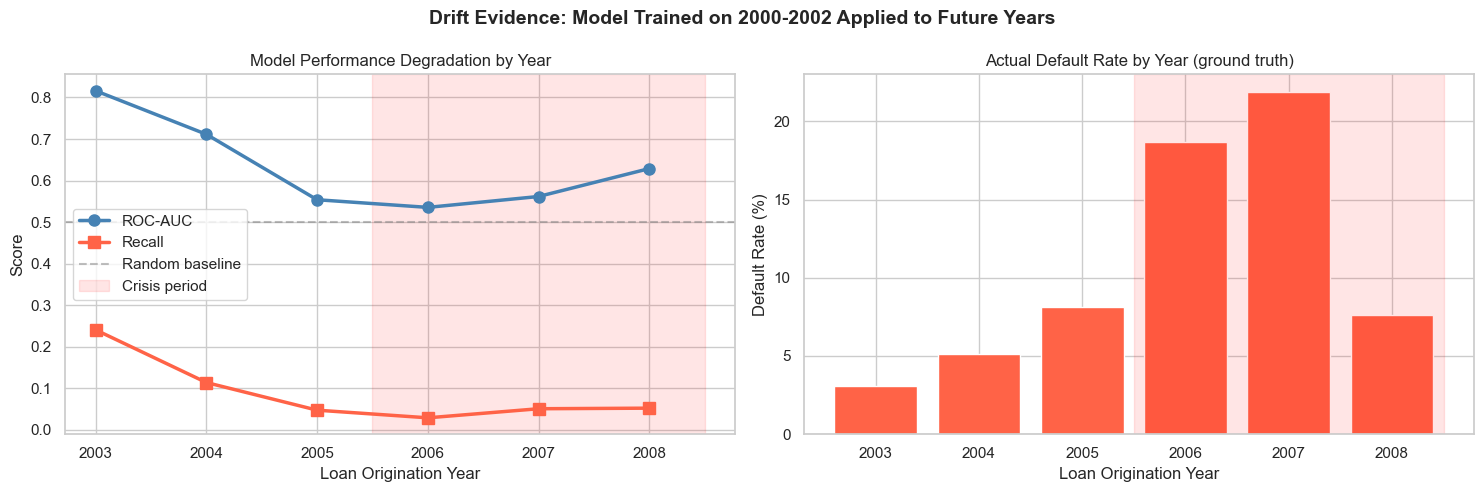

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(yearly_df['year'], yearly_df['roc_auc'], marker='o',
             color='steelblue', linewidth=2.5, markersize=8, label='ROC-AUC')
axes[0].plot(yearly_df['year'], yearly_df['recall'], marker='s',
             color='tomato', linewidth=2.5, markersize=8, label='Recall')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].axvspan(2005.5, 2008.5, alpha=0.1, color='red', label='Crisis period')
axes[0].set_title('Model Performance Degradation by Year')
axes[0].set_xlabel('Loan Origination Year')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[1].bar(yearly_df['year'], yearly_df['default_rate'] * 100,
            color='tomato', edgecolor='white')
axes[1].axvspan(2005.5, 2008.5, alpha=0.1, color='red')
axes[1].set_title('Actual Default Rate by Year (ground truth)')
axes[1].set_xlabel('Loan Origination Year')
axes[1].set_ylabel('Default Rate (%)')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.suptitle('Drift Evidence: Model Trained on 2000-2002 Applied to Future Years',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. SHAP Explainability

Loading the selected model and computing SHAP values to understand which
features drive its default predictions.

In [8]:
# Rebuild a sample of features_test to explain (reuse the model_train transformers)
import sys
sys.path.insert(0, '../src')

from mortgage_default.pipelines.model_train.nodes import (
    drop_unused_columns,
    engineer_date_features,
    apply_feature_transformers,
)
import pickle

with open('../data/04_feature/feature_transformers.pkl', 'rb') as f:
    feature_transformers = pickle.load(f)

test_subset = full_data[full_data['year'] >= 2003].drop(columns=['year']).copy()
test_subset = drop_unused_columns(test_subset)
test_subset = engineer_date_features(test_subset)
test_subset = apply_feature_transformers(test_subset, feature_transformers)

X_test_full = test_subset.reindex(columns=feature_columns, fill_value=0)

# Sample for SHAP (faster, still representative)
sample_size = min(500, len(X_test_full))
X_sample = X_test_full.sample(n=sample_size, random_state=42)

print(f'SHAP sample size: {len(X_sample)}')
X_sample.head()

SHAP sample size: 500


,credit_score,first_time_homebuyer_flag,mi_percentage,number_of_units,occupancy_status,original_cltv,original_dti,original_upb,original_ltv,original_interest_rate,...,property_type,loan_purpose,original_loan_term,number_of_borrowers,interest_only_indicator,first_payment_date_year,first_payment_date_month,maturity_date_year,maturity_date_month,loan_term_months
343570,691.0,0,0.0,1,1,95.0,29.0,417000,79.0,6.000,...,4,2,360,2,1,2007,7,2037,6,359
307622,677.0,2,35.0,1,1,100.0,62.0,79000,100.0,6.625,...,4,2,360,2,0,2006,6,2036,5,359
285652,745.0,0,25.0,1,1,89.0,40.0,270000,89.0,6.375,...,4,0,360,1,0,2005,12,2035,11,359
11474,671.0,0,0.0,1,1,100.0,27.0,192000,80.0,6.000,...,4,2,360,2,0,2005,5,2035,4,359
287588,705.0,0,0.0,1,1,65.0,33.0,224000,65.0,6.375,...,4,1,360,1,0,2006,2,2036,1,359


In [9]:
# The model is a sklearn Pipeline (imputer + classifier). SHAP needs the
# final classifier; we explain through the full pipeline's predict_proba.

def predict_default_probability(data):
    df = pd.DataFrame(data, columns=X_sample.columns)
    return model.predict_proba(df)[:, 1]

X_sample = X_sample.apply(pd.to_numeric, errors='coerce').fillna(0).astype('float64')

background_size = min(50, len(X_sample))
background = shap.sample(X_sample, background_size, random_state=42)

explainer = shap.Explainer(predict_default_probability, background)
explanation = explainer(X_sample)

print('SHAP values computed.')

PermutationExplainer explainer: 501it [00:24, 15.50it/s]                         

SHAP values computed.


C:\Users\migue\AppData\Local\Temp\ipykernel_24448\2943030110.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation, X_sample, show=False, max_display=15)


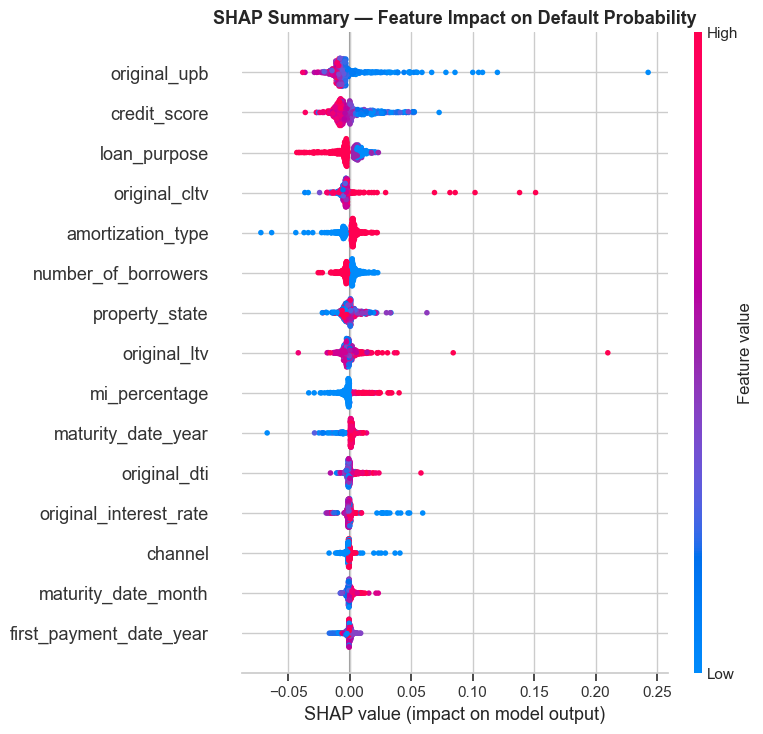

In [10]:
shap.summary_plot(explanation, X_sample, show=False, max_display=15)
plt.title('SHAP Summary — Feature Impact on Default Probability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

                feature  mean_abs_shap
           original_upb       0.011315
           credit_score       0.009845
           loan_purpose       0.007891
          original_cltv       0.005937
      amortization_type       0.005329
    number_of_borrowers       0.004601
         property_state       0.004586
           original_ltv       0.004584
          mi_percentage       0.004215
     maturity_date_year       0.002643
           original_dti       0.002578
 original_interest_rate       0.002469
                channel       0.001844
    maturity_date_month       0.001715
first_payment_date_year       0.001557


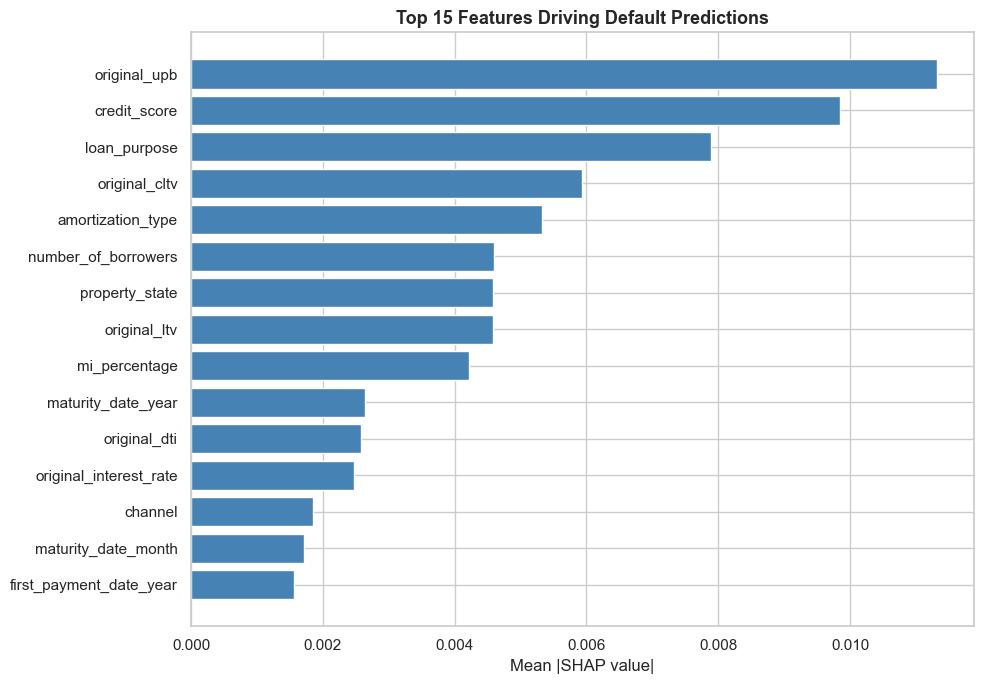

In [11]:
# Feature importance bar chart (mean absolute SHAP value)
mean_abs_shap = np.abs(explanation.values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['mean_abs_shap'], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 15 Features Driving Default Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Calibration: Predicted Probability vs Actual Default Rate

Checks whether predicted probabilities are meaningful — e.g. loans the model
scored at 20% risk should actually default around 20% of the time.

   prob_bucket  n_loans  actual_default_rate  mean_predicted_prob
(-0.001, 0.05]   263785             0.096351             0.009850
   (0.05, 0.1]    15404             0.161127             0.069623
   (0.1, 0.15]     4923             0.184440             0.121166
   (0.15, 0.2]     2039             0.202550             0.171916
    (0.2, 0.3]     1557             0.220938             0.239767
    (0.3, 0.5]      722             0.218837             0.370914
    (0.5, 1.0]      201             0.318408             0.619004


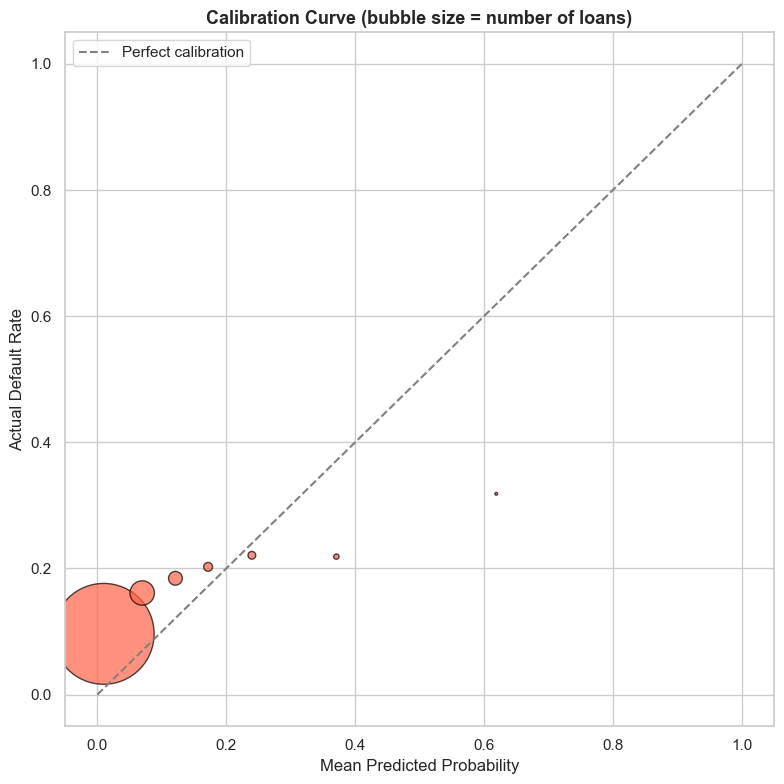

In [12]:
predictions['prob_bucket'] = pd.cut(
    predictions['probability_default'],
    bins=[0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0],
    include_lowest=True,
)

calibration = predictions.groupby('prob_bucket', observed=True).agg(
    n_loans=('actual_default', 'count'),
    actual_default_rate=('actual_default', 'mean'),
    mean_predicted_prob=('probability_default', 'mean'),
).reset_index()

print(calibration.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.scatter(calibration['mean_predicted_prob'], calibration['actual_default_rate'],
           s=calibration['n_loans'] / 50, color='tomato', alpha=0.7, edgecolor='black')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Default Rate')
ax.set_title('Calibration Curve (bubble size = number of loans)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Summary for the Report

Key numbers to cite in the written report.

In [13]:
print('=== Summary for report ===')
print(f"Selected model: {best_family}")
print(f"Decision threshold: {final_metrics['selected_threshold']:.4f} (maximize_f1 strategy)")
print()
print(f"Validation ROC-AUC (2000-2002): {val_summary.get('val_roc_auc', float('nan')):.3f}")
print(f"Test ROC-AUC (2003-2008):       {final_metrics.get('final_test_roc_auc', float('nan')):.3f}")
print(f"AUC degradation: {(val_summary.get('val_roc_auc', 0) - final_metrics.get('final_test_roc_auc', 0)) / val_summary.get('val_roc_auc', 1) * 100:.1f}%")
print()
print(f"Validation Recall: {val_summary.get('val_recall', float('nan')):.3f}")
print(f"Test Recall:       {final_metrics.get('final_test_recall', float('nan')):.3f}")
print(f"Recall degradation: {(val_summary.get('val_recall', 0) - final_metrics.get('final_test_recall', 0)) / val_summary.get('val_recall', 1) * 100:.1f}%")
print()
print(f"Top 3 SHAP features: {', '.join(importance_df.head(3)['feature'].tolist())}")
print()
print(f"Worst-performing test year: {yearly_df.loc[yearly_df['roc_auc'].idxmin(), 'year']:.0f} "
      f"(AUC: {yearly_df['roc_auc'].min():.3f})")

=== Summary for report ===
Selected model: gradient_boosting
Decision threshold: 0.1062 (maximize_f1 strategy)

Validation ROC-AUC (2000-2002): 0.864
Test ROC-AUC (2003-2008):       0.601
AUC degradation: 30.4%

Validation Recall: 0.334
Test Recall:       0.057
Recall degradation: 82.9%

Top 3 SHAP features: original_upb, credit_score, loan_purpose

Worst-performing test year: 2006 (AUC: 0.536)
